### 数据集

In [111]:
import numpy as np
import matplotlib.pyplot as plt

In [112]:
from sklearn.datasets import make_blobs  # 导入生成聚类数据集的工具
X, y = make_blobs(     # 生成一个二维二分类数据集
    n_samples=40,      # 样本数量
    centers=2,         # 类别（聚类中心）数量
    random_state=0)

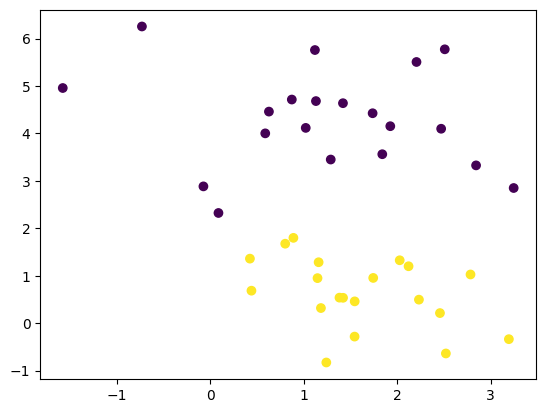

In [113]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

### sklearn中的线性SVM

In [114]:
from sklearn.svm import LinearSVC

In [115]:
clf = LinearSVC(C=1)  # 创建线性支持向量机分类模型。C：正则化参数，C 越大越重视训练集分类正确，C 越小正则化越强

In [116]:
clf.fit(X, y);

In [117]:
clf.score(X, y)

1.0

In [118]:
def decision_boundary_plot(X, y, clf):
    axis_x1_min, axis_x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    axis_x2_min, axis_x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    x1, x2 = np.meshgrid(
        np.arange(axis_x1_min, axis_x1_max, 0.01),
        np.arange(axis_x2_min, axis_x2_max, 0.01))

    z = clf.predict(np.c_[x1.ravel(), x2.ravel()])
    z = z.reshape(x1.shape)

    from matplotlib.colors import ListedColormap
    custom_cmap = ListedColormap(['#F5B9EF', '#BBFFBB', '#F9F9CB'])

    plt.contourf(x1, x2, z, cmap=custom_cmap)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.show()

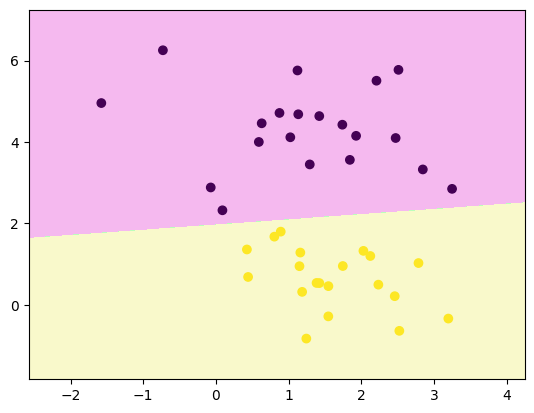

In [119]:
decision_boundary_plot(X, y, clf)

In [120]:
def plot_svm_margin(X, y, clf, ax=None):
    from sklearn.inspection import DecisionBoundaryDisplay  # 导入决策边界可视化工具
    DecisionBoundaryDisplay.from_estimator(  # 根据已经训练好的 SVM 模型绘制决策边界和间隔线
        clf,                            # 已训练好的 SVM 分类器
        X,                              # 二维特征数据
        ax=ax,                          # 指定绘图坐标轴，None 表示自动创建
        grid_resolution=50,             # 网格分辨率，越大边界越平滑
        plot_method="contour",          # 使用等高线方式绘制
        colors="k",                     # 边界线颜色为黑色
        levels=[-1, 0, 1],              # -1、1 为间隔线，0 为决策边界
        alpha=0.5,                      # 设置线条透明度
        linestyles=["--", "-", "--"])   # 两侧间隔线为虚线，中间决策边界为实线
    plt.scatter(X[:, 0], X[:, 1], c=y)  # 绘制原始样本点，并根据类别 y 使用不同颜色显示

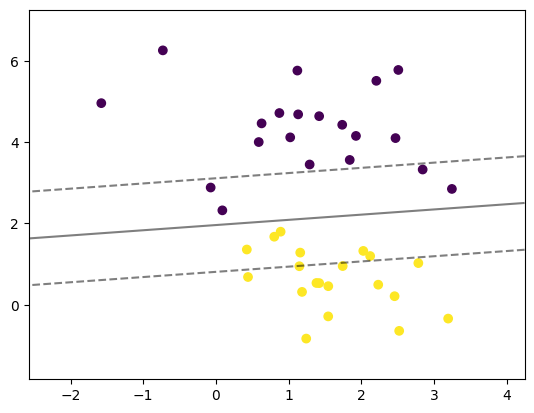

In [121]:
plot_svm_margin(X, y, clf)  # 调用函数，绘制 SVM 的决策边界和间隔
plt.show()

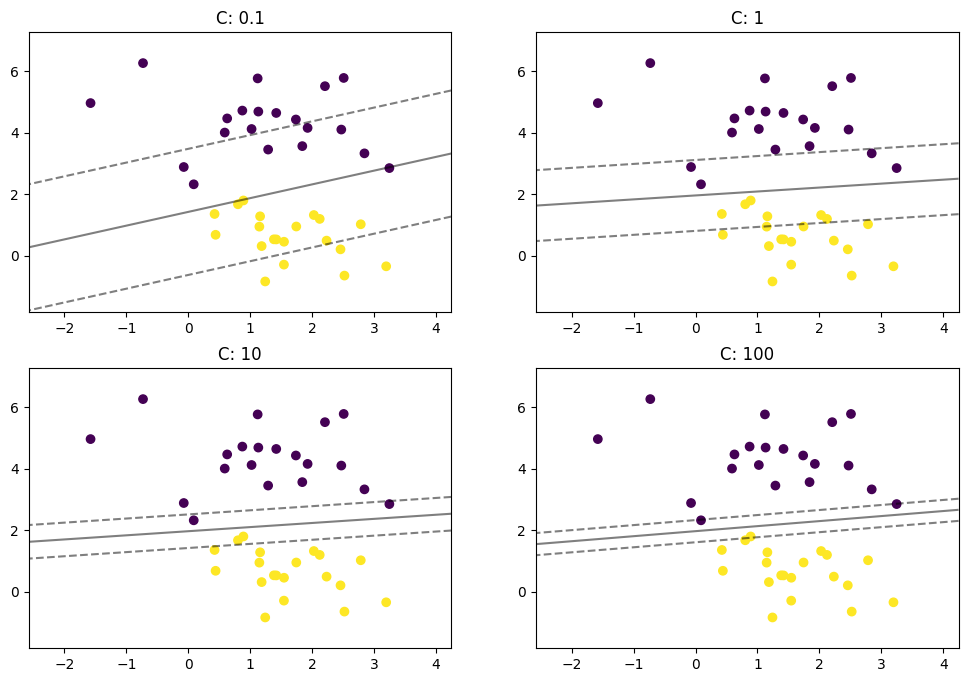

In [122]:
plt.figure(figsize=(12, 8))  # 创建当前画布，并设置当前图像大小
params = [0.1, 1, 10, 100]   # 设置不同的 C 值，用于观察正则化强度对 SVM 决策边界的影响
for i, c in enumerate(params):  # 依次使用不同的 C 值训练 LinearSVC
    clf = LinearSVC(C=c, random_state=0)  # 创建线性 SVM 分类器
    clf.fit(X, y)  # 使用训练数据拟合模型
    ax = plt.subplot(2, 2, i + 1)  # 创建 2×2 子图，并指定当前绘图位置
    plt.title("C: {0}".format(c))  # 设置当前子图标题，显示对应的 C 值
    plot_svm_margin(X, y, clf, ax)  # 绘制样本点、决策边界以及 SVM 间隔线
plt.show()

### 线性SVM多分类任务

In [123]:
from sklearn import datasets
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [124]:
clf = LinearSVC(C=0.1, multi_class="ovr", random_state=0)
clf.fit(X, y);

In [125]:
clf.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])